# Modeling

Forecast daily store sales and pick the best model. We compare four, in increasing strength:

1. **Baseline** — each store's historical average. The floor every real model must beat.
2. **Linear Regression** — a simple, fast ML reference.
3. **Random Forest** — strong tree ensemble (trained on a subsample — see why below).
4. **XGBoost** — boosted trees; the model `src/train.py` will productionize.

Then a separate **ARIMA demonstration** on a single store to show classical time-series — and why it isn't the
production choice here.

Key rule: the train/validation split is **by time** (last 6 weeks held out), never random — a random split lets the
model peek at the future, which is meaningless for forecasting.

### 0. Setup & Load Features

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

params = yaml.safe_load(open("../params.yaml"))
target   = params["features"]["target"]        # "Sales"
log_tgt  = params["features"]["log_target"]     # True -> train in log space
test_weeks = params["data"]["test_weeks"]       # 6

df = pd.read_parquet("../data/processed/features.parquet")
feature_cols = list(json.load(open("../models/feature_columns.json")).values())
print("rows:", f"{len(df):,}", "| features:", len(feature_cols))

rows: 844,392 | features: 31


### 1. Time-based train / validation split

Sort by date, hold out the final `test_weeks` weeks as validation — mirrors "train on the past, forecast the next 6 weeks."

In [6]:
df = df.sort_values("Date")
cutoff = df["Date"].max() - pd.Timedelta(weeks=test_weeks)

train_df = df[df["Date"] <= cutoff]
val_df   = df[df["Date"] >  cutoff]
print("train:", f"{len(train_df):,}", "| val:", f"{len(val_df):,}")
print("val window:", val_df["Date"].min().date(), "->", val_df["Date"].max().date())

X_train = train_df[feature_cols].astype(float)
X_val   = val_df[feature_cols].astype(float)
y_train = np.log1p(train_df[target]) if log_tgt else train_df[target]
y_val   = np.log1p(val_df[target])   if log_tgt else val_df[target]

train: 804,110 | val: 40,282
val window: 2015-06-20 -> 2015-07-31


### 2. Metric helper (report in euros)

Predictions come back as logs; invert with `expm1` **before** computing metrics, else they're meaningless "log units."
MAPE skips zero-sales rows (can't divide by 0).

In [7]:
def to_euros(y):
    return np.expm1(y) if log_tgt else np.asarray(y)

def evaluate(name, y_true, y_pred):
    yt, yp = to_euros(np.asarray(y_true)), to_euros(np.asarray(y_pred))
    mask = yt > 0
    return {
        "model": name,
        "MAE":  mean_absolute_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAPE%": (np.abs((yt[mask] - yp[mask]) / yt[mask])).mean() * 100,
    }

results = []

### 3. Baseline - Each store's average

In [8]:
store_mean  = y_train.groupby(train_df["Store"]).mean()
global_mean = y_train.mean()
base_pred = val_df["Store"].map(store_mean).fillna(global_mean)

results.append(evaluate("Baseline (store mean)", y_val, base_pred))
results[-1]

{'model': 'Baseline (store mean)',
 'MAE': 1440.6204640193318,
 'RMSE': np.float64(1954.788264275563),
 'MAPE%': np.float64(21.89759877029956)}

### 4. Linear Regression

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_val)

results.append(evaluate("Linear Regression", y_val, lr_pred))
results[-1]

{'model': 'Linear Regression',
 'MAE': 1862.3943051884098,
 'RMSE': np.float64(2658.306054018421),
 'MAPE%': np.float64(28.5496753376887)}

### 5. Random Forest Regressor

In [10]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20, 
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)

results.append(evaluate("Random Forest", y_val, rf_pred))
results[-1]

{'model': 'Random Forest',
 'MAE': 884.4351729069979,
 'RMSE': np.float64(1323.4242424285019),
 'MAPE%': np.float64(12.852783080252006)}

### 6. XGBoost

Hyperparameters from `params.yaml`; `tree_method="hist"` keeps it fast and it trains on the **full** data.

In [11]:
m = params["model"]
xgb_model = xgb.XGBRegressor(
    n_estimators=m["n_estimators"],
    max_depth=m["max_depth"],
    learning_rate=m["learning_rate"],
    subsample=m["subsample"],
    colsample_bytree=m["colsample_bytree"],
    random_state=m["random_state"],
    tree_method="hist",
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_val)

results.append(evaluate("XGBoost", y_val, xgb_pred))
results[-1]

{'model': 'XGBoost',
 'MAE': 739.1053658681394,
 'RMSE': np.float64(1070.108403699954),
 'MAPE%': np.float64(11.043303702009453)}

### 7. Compare

,MAE,RMSE,MAPE%
model,,,
XGBoost,739.1,1070.1,11.0
Random Forest,884.4,1323.4,12.9
Baseline (store mean),1440.6,1954.8,21.9
Linear Regression,1862.4,2658.3,28.5


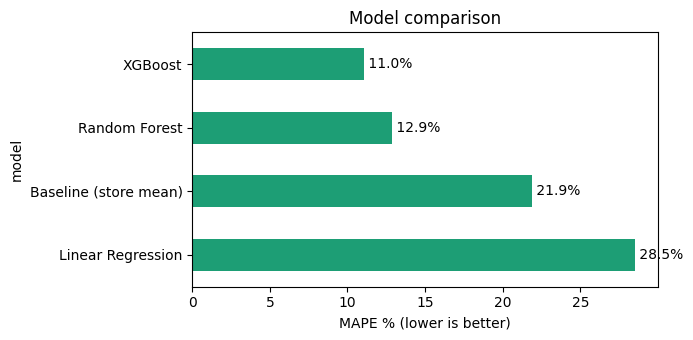

In [13]:
scores = pd.DataFrame(results).set_index("model").sort_values("MAPE%")
display(scores.round(1))

# visual: MAPE by model (lower = better)
ax = scores["MAPE%"].plot.barh(figsize=(7, 3.5), color="#1D9E75")
ax.invert_yaxis()                      # best model on top
ax.set_xlabel("MAPE % (lower is better)")
ax.set_title("Model comparison")
for i, v in enumerate(scores["MAPE%"]):
    ax.text(v, i, f" {v:.1f}%", va="center")
plt.tight_layout(); plt.show()

### 8. Actual vs. predicted (XGBoost)

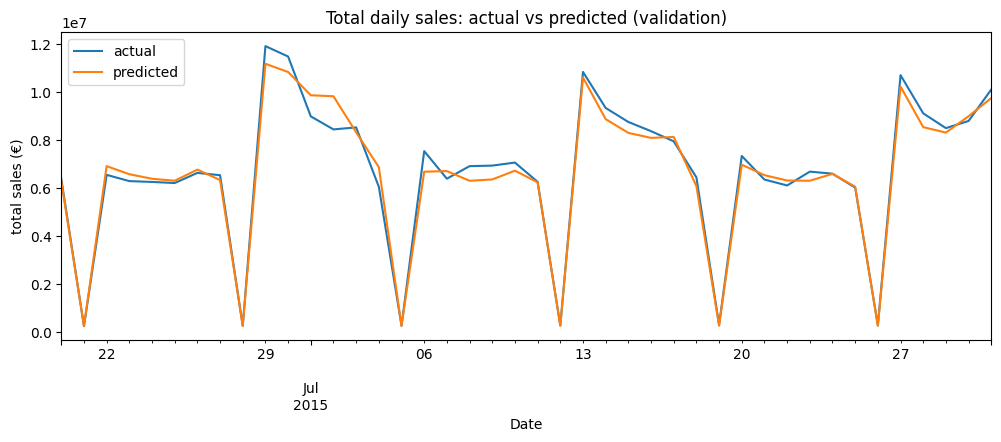

In [14]:
plot_df = val_df[["Date", target]].copy()
plot_df["pred"] = to_euros(xgb_pred)
daily = plot_df.groupby("Date").agg(actual=(target, "sum"), predicted=("pred", "sum"))

daily.plot(figsize=(12, 4), title="Total daily sales: actual vs predicted (validation)")
plt.ylabel("total sales (€)"); plt.show()

### 9. Feature Importance - the demand drivers

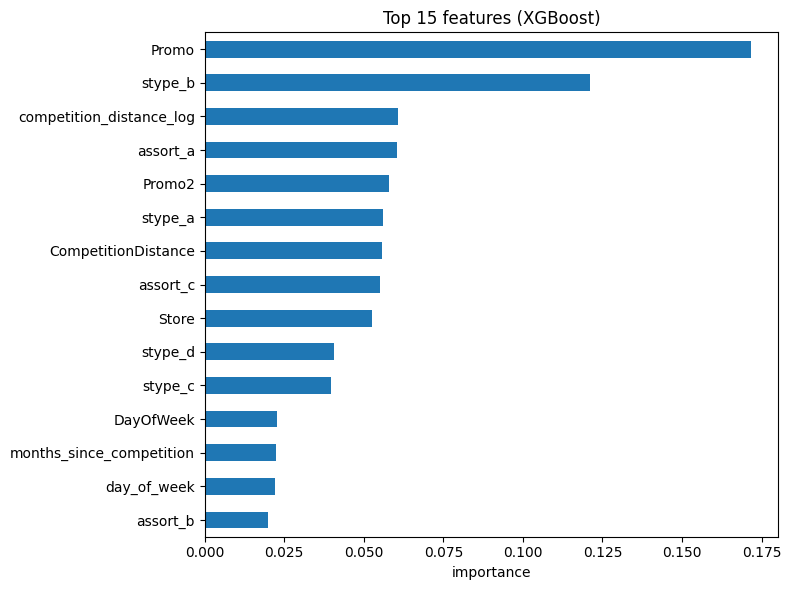

In [15]:
imp = (pd.Series(xgb_model.feature_importances_, index=feature_cols)
         .sort_values(ascending=False).head(15))
imp.iloc[::-1].plot.barh(figsize=(8, 6), title="Top 15 features (XGBoost)")
plt.xlabel("importance"); plt.tight_layout(); plt.show()